# Stunting Data Trust Framework
## Provincial-level analysis of SSGI 2022 and SKI 2023 as two independent signals

This notebook implements the empirical component of the essay. SSGI (Survei Status Gizi Indonesia) and SKI (Survei Kesehatan Indonesia) are treated as two independent, imperfect measurements of an unobserved true stunting prevalence, rather than as one correct figure and one that needs correcting. All figures used below come from a single published Ministry of Health source and no value is simulated, projected, or interpolated.

Scope note. The original concept for this essay described a district level (kabupaten/kota) comparison between SKI 2023 and SSGI 2024. At the time this notebook was prepared, a complete and independently verifiable district level table for SSGI 2024 could not be confirmed, and e-PPGBM records require an authenticated login, so both are excluded from the quantitative analysis. This notebook applies the same logic, fit for purpose framing, an empirical uncertainty band in place of a fabricated confidence interval, and threshold based decision risk, at the provincial level using SSGI 2022 and SKI 2023. Section 9 lists district level examples referenced elsewhere in the essay as illustrative only, pending their own source check.

Source: Ministry of Health of the Republic of Indonesia, Directorate General of Public Health (2024). Profil Program Kesehatan Masyarakat Tahun 2023, p. 10.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

pd.set_option("display.max_rows", 40)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10

DATA_PATH = "Dataset Stunting Provinsi.xlsx"
NATIONAL_TARGET_2029 = 0.142  # government target cited in Chapter I: 14.2 percent by 2029

## 1. Data loading and source documentation

In [6]:
raw = pd.read_excel(DATA_PATH, sheet_name="Data")

provinces = raw[raw["Provinsi"] != "INDONESIA (nasional)"].copy()
national_row = raw[raw["Provinsi"] == "INDONESIA (nasional)"].iloc[0]

provinces = provinces.rename(columns={
    "Prevalensi_Stunting_SSGI_2022_persen": "ssgi_2022",
    "Prevalensi_Stunting_SKI_2023_persen": "ski_2023",
    "Selisih_2023_vs_2022_poin": "selisih_reported",
    "Wilayah_Makro": "region",
    "Provinsi": "province",
    "Catatan_Data_2022": "note_2022",
}).reset_index(drop=True)

provinces["selisih"] = provinces["ski_2023"] - provinces["ssgi_2022"]
matches_reported = np.allclose(provinces["selisih"], provinces["selisih_reported"], atol=1e-6)

print(f"Provinces loaded: {len(provinces)}")
print(f"National SSGI 2022: {national_row['Prevalensi_Stunting_SSGI_2022_persen'] * 100:.1f} percent")
print(f"National SKI 2023: {national_row['Prevalensi_Stunting_SKI_2023_persen'] * 100:.1f} percent")
print(f"Recomputed difference matches the source column: {matches_reported}")

provinces.head()

Provinces loaded: 38
National SSGI 2022: 21.6 percent
National SKI 2023: 21.5 percent
Recomputed difference matches the source column: True


,Kode_BPS_Provinsi,province,region,ssgi_2022,ski_2023,selisih_reported,note_2022,selisih
0,11.0,Aceh,Sumatra,0.312,0.294,-0.018,NaN,-0.018
1,12.0,Sumatera Utara,Sumatra,0.211,0.189,-0.022,NaN,-0.022
2,13.0,Sumatera Barat,Sumatra,0.252,0.236,-0.016,NaN,-0.016
3,14.0,Riau,Sumatra,0.170,0.136,-0.034,NaN,-0.034
4,15.0,Jambi,Sumatra,0.180,0.135,-0.045,NaN,-0.045


In [7]:
meta = pd.read_excel(DATA_PATH, sheet_name="Metodologi_dan_Catatan", header=None)
for line in meta[0].dropna().tolist()[:8]:
    print(line)

JUDUL DATASET
Prevalensi Stunting Balita menurut Provinsi, Indonesia, 2022 dan 2023
CAKUPAN
38 provinsi (sesuai pemekaran wilayah per 2023) + angka nasional Indonesia. Level provinsi, bukan kabupaten/kota.
SUMBER DATA
Kolom Prevalensi_Stunting_SSGI_2022_persen dan Prevalensi_Stunting_SKI_2023_persen diambil langsung dari satu dokumen resmi Kementerian Kesehatan RI: Direktorat Jenderal Kesehatan Masyarakat (2024), Profil Program Kesehatan Masyarakat Tahun 2023, halaman 10 ("Sandingan Balita Stunting Berdasarkan Hasil SSGI 2022 dan SKI 2023 menurut Provinsi"). Dokumen ini sendiri mengompilasi hasil Survei Status Gizi Indonesia (SSGI) 2022 dan Survei Kesehatan Indonesia (SKI) 2023, keduanya dilaksanakan oleh Badan Kebijakan Pembangunan Kesehatan (BKPK) Kemenkes bekerja sama dengan BPS dan BRIN.
Tautan: https://kesprimkom.kemkes.go.id/assets/uploads/contents/others/Profil_Kesehatan_Masyarakat_Tahun_2023.pdf
KETERBATASAN YANG HARUS DICANTUMKAN DI ESSAY


A caveat that carries through the rest of the notebook: four provinces (Papua Selatan, Papua Tengah, Papua Pegunungan, Papua Barat Daya) were created after the SSGI 2022 fieldwork, so their 2022 baseline in the source table is inherited from the parent province. Any difference computed for these four therefore mixes real change with a reporting artifact of the 2022 to 2023 provincial split, and is flagged rather than dropped.

In [8]:
flagged = provinces[provinces["note_2022"].notna()][["province", "ssgi_2022", "ski_2023", "note_2022"]]
flagged

,province,ssgi_2022,ski_2023,note_2022
34,Papua Selatan,0.346,0.250,Nilai SSGI 2022 mengikuti angka Papua (belum d...
35,Papua Tengah,0.346,0.394,Nilai SSGI 2022 mengikuti angka Papua (belum d...
36,Papua Pegunungan,0.346,0.373,Nilai SSGI 2022 mengikuti angka Papua (belum d...
37,Papua Barat Daya,0.300,0.310,Nilai SSGI 2022 mengikuti angka Papua Barat (b...


## 2. Descriptive overview by macro region

In [9]:
region_summary = provinces.groupby("region")[["ssgi_2022", "ski_2023"]].agg(["mean", "min", "max"])
(region_summary * 100).round(1)

ssgi_2022             ski_2023            
                          mean   min   max     mean   min   max
region                                                         
Bali & Nusa Tenggara      25.3   8.0  35.3     23.2   7.2  37.9
Jawa                      18.6  14.8  20.8     20.0  17.6  24.0
Kalimantan                25.1  22.1  27.8     21.8  17.4  24.7
Maluku & Papua            31.3  26.1  34.6     29.8  23.7  39.4
Sulawesi                  27.1  20.5  35.0     27.2  21.3  30.3
Sumatra                   20.0  15.2  31.2     19.2  13.5  29.4

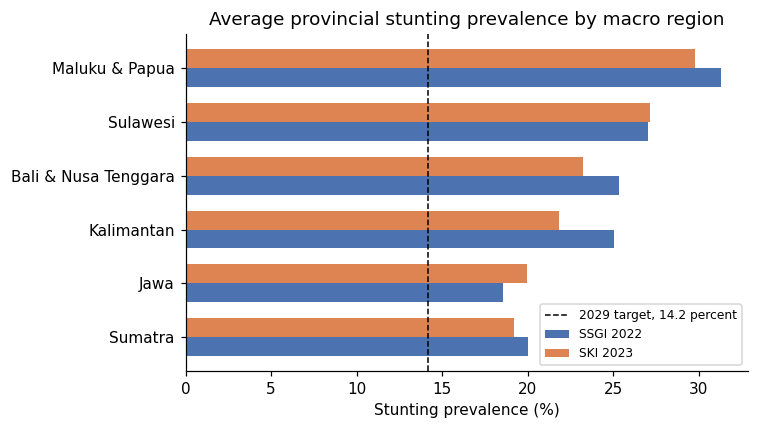

In [10]:
region_means = provinces.groupby("region")[["ssgi_2022", "ski_2023"]].mean().sort_values("ski_2023")

fig, ax = plt.subplots(figsize=(7, 4))
y = np.arange(len(region_means))
h = 0.35
ax.barh(y - h / 2, region_means["ssgi_2022"] * 100, height=h, label="SSGI 2022", color="#4C72B0")
ax.barh(y + h / 2, region_means["ski_2023"] * 100, height=h, label="SKI 2023", color="#DD8452")
ax.set_yticks(y)
ax.set_yticklabels(region_means.index)
ax.axvline(NATIONAL_TARGET_2029 * 100, color="black", linestyle="--", linewidth=1, label="2029 target, 14.2 percent")
ax.set_xlabel("Stunting prevalence (%)")
ax.set_title("Average provincial stunting prevalence by macro region")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

East to west disparity is visible here and feeds directly into the SDG 10 argument in Chapter I: Maluku and Papua and, to a lesser extent, Bali and Nusa Tenggara, carry the highest average prevalence under both surveys, while Bali and Jawa sit well below the national figure.

## 3. Discordance between the two surveys

If SSGI and SKI were measuring the same thing without error, the difference below would center on zero with a narrow spread. The extent to which it does not is itself the evidence for treating the two as separate signals rather than duplicate readings of one truth.

In [11]:
selisih_pct = (provinces["selisih"] * 100)
print(selisih_pct.describe().round(2))

top_increase = provinces.sort_values("selisih", ascending=False).head(5)[["province", "ssgi_2022", "ski_2023", "selisih", "note_2022"]]
top_decrease = provinces.sort_values("selisih").head(5)[["province", "ssgi_2022", "ski_2023", "selisih", "note_2022"]]

print("\nLargest increase, SKI 2023 relative to SSGI 2022")
print(top_increase.to_string(index=False))
print("\nLargest decrease, SKI 2023 relative to SSGI 2022")
print(top_decrease.to_string(index=False))

count    38.00
mean     -0.90
std       3.48
min      -9.60
25%      -3.15
50%      -0.20
75%       1.68
max       4.80
Name: selisih, dtype: float64

Largest increase, SKI 2023 relative to SSGI 2022
        province  ssgi_2022  ski_2023  selisih                                                            note_2022
    Papua Tengah      0.346     0.394    0.048 Nilai SSGI 2022 mengikuti angka Papua (belum dimekarkan saat survei)
          Banten      0.200     0.240    0.040                                                                  NaN
       Gorontalo      0.238     0.269    0.031                                                                  NaN
     DKI Jakarta      0.148     0.176    0.028                                                                  NaN
Papua Pegunungan      0.346     0.373    0.027 Nilai SSGI 2022 mengikuti angka Papua (belum dimekarkan saat survei)

Largest decrease, SKI 2023 relative to SSGI 2022
           province  ssgi_2022  ski_2023  selisih     

Three of the ten provinces above carry the Papua baseline flag from Section 1, so their ranking here should be read as partly a reporting artifact rather than a purely descriptive year on year movement.

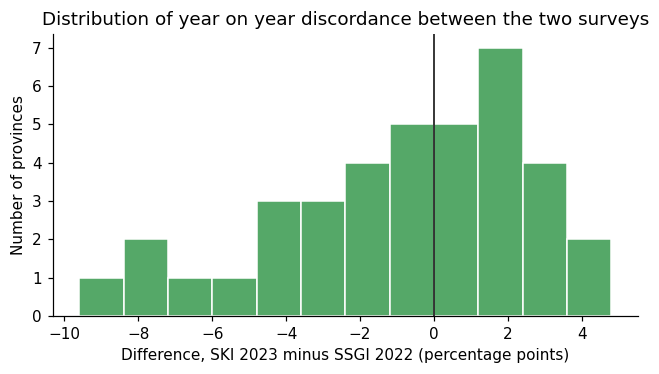

In [12]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(selisih_pct, bins=12, color="#55A868", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Difference, SKI 2023 minus SSGI 2022 (percentage points)")
ax.set_ylabel("Number of provinces")
ax.set_title("Distribution of year on year discordance between the two surveys")
plt.tight_layout()
plt.show()

## 4. An empirical uncertainty band in place of a fabricated confidence interval

The published SSGI and SKI summary tables used here do not report standard errors, so building a formal confidence interval would mean inventing a number the source does not provide. Instead, for each province the two independent point estimates are treated as the bounds of a plausible range: the true prevalence probably sits somewhere between what SSGI 2022 and SKI 2023 each recorded. A province is then flagged by where the 2029 national target of 14.2 percent falls relative to that range.

In [13]:
provinces["lower"] = provinces[["ssgi_2022", "ski_2023"]].min(axis=1)
provinces["upper"] = provinces[["ssgi_2022", "ski_2023"]].max(axis=1)
provinces["band_width"] = provinces["upper"] - provinces["lower"]

def classify_risk(row, threshold=NATIONAL_TARGET_2029, near_margin=0.02):
    if row["lower"] <= threshold <= row["upper"]:
        return "high, target falls inside the two-source band"
    distance = min(abs(row["lower"] - threshold), abs(row["upper"] - threshold))
    if distance <= near_margin:
        return "watch, estimate close to the target"
    return "low, estimate consistently far from the target"

provinces["decision_risk"] = provinces.apply(classify_risk, axis=1)
provinces["decision_risk"].value_counts()

,count
decision_risk,
"low, estimate consistently far from the target",33
"watch, estimate close to the target",3
"high, target falls inside the two-source band",2


In [14]:
risk_table = provinces[provinces["decision_risk"] != "low, estimate consistently far from the target"].sort_values("lower")
risk_table[["province", "region", "ssgi_2022", "ski_2023", "decision_risk"]]

,province,region,ssgi_2022,ski_2023,decision_risk
4,Jambi,Sumatra,0.180,0.135,"high, target falls inside the two-source band"
3,Riau,Sumatra,0.170,0.136,"high, target falls inside the two-source band"
10,DKI Jakarta,Jawa,0.148,0.176,"watch, estimate close to the target"
7,Lampung,Sumatra,0.152,0.149,"watch, estimate close to the target"
9,Kepulauan Riau,Sumatra,0.154,0.168,"watch, estimate close to the target"


No province's band straddles 14.2 percent outright at this level of aggregation, which is expected given how coarse a provincial average is. What the band does surface is a smaller set of provinces sitting close enough to the target that which survey a planner consults could change whether that province still reads as off track. DKI Jakarta and Lampung fall into this watch category and are worth naming explicitly in Chapter II as boundary cases for the fit for purpose protocol, since a province this close to target is exactly where a wrong data choice carries the highest policy cost.

## 5. Priority ranking stability across the two surveys

A province's absolute prevalence matters less for budget allocation than its rank relative to other provinces. This section checks how much that rank order shifts between the two surveys.

In [15]:
provinces["rank_2022"] = provinces["ssgi_2022"].rank(ascending=False, method="min").astype(int)
provinces["rank_2023"] = provinces["ski_2023"].rank(ascending=False, method="min").astype(int)
provinces["rank_change"] = provinces["rank_2022"] - provinces["rank_2023"]

rho, pval = spearmanr(provinces["rank_2022"], provinces["rank_2023"])
print(f"Spearman rank correlation between the two priority orderings: {rho:.3f} (p = {pval:.4f})")
print("Positive rank_change means the province moved toward the top of the priority list in 2023.")

movers = provinces.reindex(provinces["rank_change"].abs().sort_values(ascending=False).index).head(8)
movers[["province", "region", "rank_2022", "rank_2023", "rank_change"]]

Spearman rank correlation between the two priority orderings: 0.883 (p = 0.0000)
Positive rank_change means the province moved toward the top of the priority list in 2023.


,province,region,rank_2022,rank_2023,rank_change
19,Kalimantan Barat,Kalimantan,12,25,-13
23,Kalimantan Utara,Kalimantan,22,33,-11
15,Banten,Jawa,27,17,10
34,Papua Selatan,Maluku & Papua,3,13,-10
28,Gorontalo,Sulawesi,21,12,9
17,Nusa Tenggara Barat,Bali & Nusa Tenggara,7,16,-9
27,Sulawesi Tenggara,Sulawesi,13,6,7
30,Maluku,Maluku & Papua,16,9,7


The overall ordering is broadly stable, which supports using either source for coarse, provincial level planning. The provinces that move several places, however, are precisely the ones a fit for purpose protocol needs to name, since a shift of that size can change whether a province clears a funding cutoff.

## 6. A composite priority watch score

The three quantities above (closeness to the national target, size of the discordance between surveys, and rank instability) are combined into a single illustrative score. The weighting below reflects the essay's emphasis on threshold proximity as the main driver of decision risk; it is a transparent, adjustable heuristic rather than a fitted or validated model, and is presented as such.

In [16]:
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

distance_to_target = provinces.apply(
    lambda r: min(abs(r["lower"] - NATIONAL_TARGET_2029), abs(r["upper"] - NATIONAL_TARGET_2029)),
    axis=1,
)

provinces["risk_threshold_proximity"] = 1 - minmax(distance_to_target)
provinces["risk_discordance"] = minmax(provinces["selisih"].abs())
provinces["risk_rank_instability"] = minmax(provinces["rank_change"].abs())

provinces["priority_watch_score"] = (
    0.5 * provinces["risk_threshold_proximity"]
    + 0.3 * provinces["risk_discordance"]
    + 0.2 * provinces["risk_rank_instability"]
)

watch_list = provinces.sort_values("priority_watch_score", ascending=False).head(10)
watch_list[["province", "region", "ssgi_2022", "ski_2023", "decision_risk", "priority_watch_score"]]

,province,region,ssgi_2022,ski_2023,decision_risk,priority_watch_score
19,Kalimantan Barat,Kalimantan,0.278,0.206,"low, estimate consistently far from the target",0.782747
23,Kalimantan Utara,Kalimantan,0.221,0.174,"low, estimate consistently far from the target",0.751079
4,Jambi,Sumatra,0.180,0.135,"high, target falls inside the two-source band",0.713431
34,Papua Selatan,Maluku & Papua,0.346,0.250,"low, estimate consistently far from the target",0.705066
10,DKI Jakarta,Jawa,0.148,0.176,"watch, estimate close to the target",0.662186
17,Nusa Tenggara Barat,Bali & Nusa Tenggara,0.327,0.246,"low, estimate consistently far from the target",0.652069
3,Riau,Sumatra,0.170,0.136,"high, target falls inside the two-source band",0.650364
15,Banten,Jawa,0.200,0.240,"low, estimate consistently far from the target",0.650175
13,DI Yogyakarta,Jawa,0.164,0.180,"low, estimate consistently far from the target",0.569882
8,Kepulauan Bangka Belitung,Sumatra,0.185,0.206,"low, estimate consistently far from the target",0.565222


## 7. Visual summary

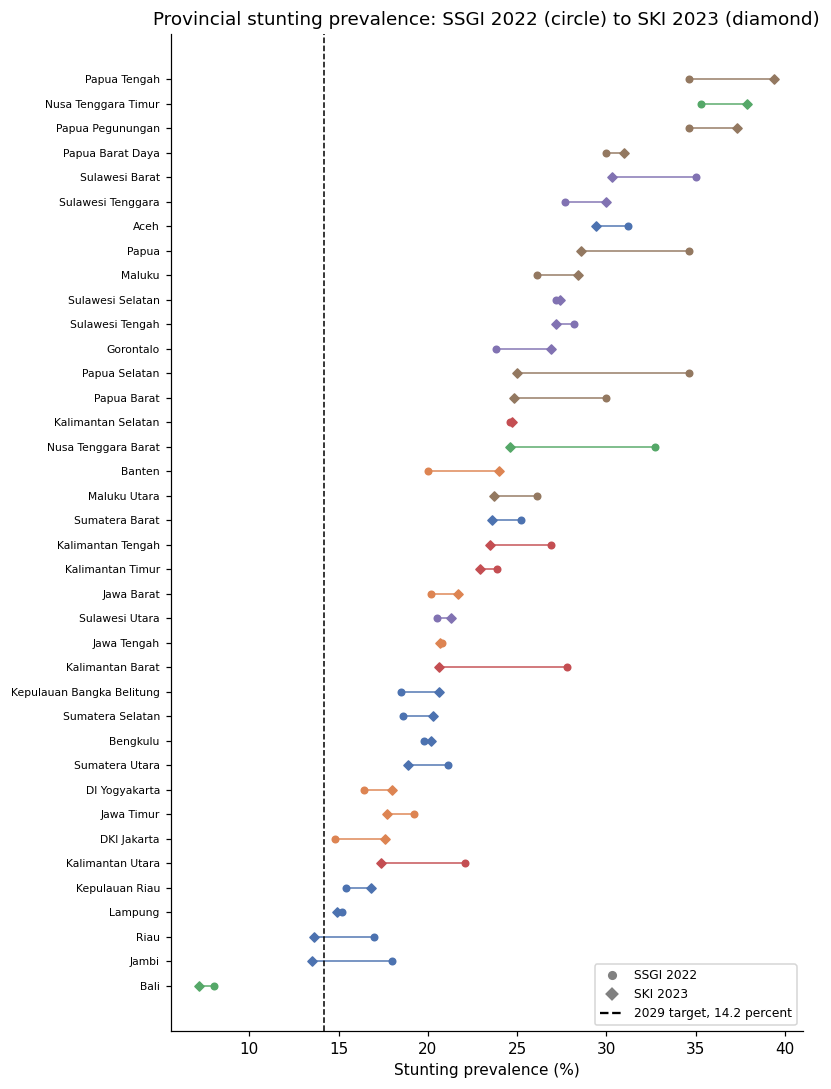

In [17]:
region_colors = {
    "Sumatra": "#4C72B0",
    "Jawa": "#DD8452",
    "Bali & Nusa Tenggara": "#55A868",
    "Kalimantan": "#C44E52",
    "Sulawesi": "#8172B2",
    "Maluku & Papua": "#937860",
}

plot_df = provinces.sort_values("ski_2023").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 10))
for i, row in plot_df.iterrows():
    color = region_colors.get(row["region"], "gray")
    ax.plot([row["ssgi_2022"] * 100, row["ski_2023"] * 100], [i, i], color=color, linewidth=1.2, alpha=0.8)
    ax.scatter(row["ssgi_2022"] * 100, i, color=color, marker="o", s=18, zorder=3)
    ax.scatter(row["ski_2023"] * 100, i, color=color, marker="D", s=18, zorder=3)

ax.axvline(NATIONAL_TARGET_2029 * 100, color="black", linestyle="--", linewidth=1)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["province"], fontsize=7)
ax.set_xlabel("Stunting prevalence (%)")
ax.set_title("Provincial stunting prevalence: SSGI 2022 (circle) to SKI 2023 (diamond)")

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", label="SSGI 2022", markersize=7),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="gray", label="SKI 2023", markersize=7),
    Line2D([0], [0], color="black", linestyle="--", label="2029 target, 14.2 percent"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 8. Exporting a results table for Chapter II

In [19]:
export_cols = ["province", "region", "ssgi_2022", "ski_2023", "selisih", "decision_risk", "priority_watch_score"]
export_table = provinces[export_cols].sort_values("priority_watch_score", ascending=False).reset_index(drop=True)
export_table.to_csv("chapter2_priority_watch_table.csv", index=False)
export_table.head(10)

,province,region,ssgi_2022,ski_2023,selisih,decision_risk,priority_watch_score
0,Kalimantan Barat,Kalimantan,0.278,0.206,-0.072,"low, estimate consistently far from the target",0.782747
1,Kalimantan Utara,Kalimantan,0.221,0.174,-0.047,"low, estimate consistently far from the target",0.751079
2,Jambi,Sumatra,0.180,0.135,-0.045,"high, target falls inside the two-source band",0.713431
3,Papua Selatan,Maluku & Papua,0.346,0.250,-0.096,"low, estimate consistently far from the target",0.705066
4,DKI Jakarta,Jawa,0.148,0.176,0.028,"watch, estimate close to the target",0.662186
5,Nusa Tenggara Barat,Bali & Nusa Tenggara,0.327,0.246,-0.081,"low, estimate consistently far from the target",0.652069
6,Riau,Sumatra,0.170,0.136,-0.034,"high, target falls inside the two-source band",0.650364
7,Banten,Jawa,0.200,0.240,0.040,"low, estimate consistently far from the target",0.650175
8,DI Yogyakarta,Jawa,0.164,0.180,0.016,"low, estimate consistently far from the target",0.569882
9,Kepulauan Bangka Belitung,Sumatra,0.185,0.206,0.021,"low, estimate consistently far from the target",0.565222


## 9. District level examples cited elsewhere in the essay, not used in this analysis

The wider essay references district level (kabupaten/kota) triangulation examples, including Gunung Mas, Tabalong (Puskesmas Kelua), Penajam Paser Utara, and Sanggau, comparing SSGI, SKI, and publicly disclosed e-PPGBM figures. These numbers were not independently re-verified while building this notebook and are not loaded into any dataframe above. Before they are cited in the final submission, each figure should be traced back to its original publication (SSGI buku saku, SKI 2023 hasil utama, or the specific district health office release for e-PPGBM) and the year of each figure should be checked, since at least one of the examples circulating in earlier drafts mixed an SSGI 2019 figure with more recent SKI and e-PPGBM figures for the same district.

## 10. Summary

- Fit for purpose protocol: the two surveys agree closely enough in overall ranking (Section 5) to support coarse, provincial level planning from either source, but a small set of provinces (Section 4, Section 6) sit close enough to the 2029 target that the choice of source could change their funding status. These are the provinces where a written protocol on which data source governs which decision matters most.
- Data quality and uncertainty layer: Section 4 replaces a fabricated confidence interval with an empirical band built from the two real point estimates, and Section 6 turns that band, the discordance, and the rank instability into a single transparent score rather than a single point prevalence figure.
- Probability based prioritization: the priority watch list in Section 6 operationalizes the shift the essay argues for, from asking which single number is correct to asking which provinces carry the highest risk of a wrong funding decision.

Limitations: This notebook works at the provincial level because a fully verified district level SSGI 2024 table and open e-PPGBM access were not available at the time of writing